In [ ]:
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

[INFO] Couldn't find torchinfo... installing it.


In [ ]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
torch.manual_seed(42)

train_data = torchvision.datasets.CIFAR10(
    root='CIFAR10/train',
    train=True,
    download=True,
    #transform=train_transform,
    transform=ToTensor()
)

test_data = torchvision.datasets.CIFAR10(
    root='CIFAR10/test',
    train=False,
    download=True,
    transform=ToTensor()
)

100%|██████████| 170M/170M [00:12<00:00, 13.3MB/s]


Extracting CIFAR10/train/cifar-10-python.tar.gz to CIFAR10/train


100%|██████████| 170M/170M [00:18<00:00, 9.25MB/s]


Extracting CIFAR10/test/cifar-10-python.tar.gz to CIFAR10/test


In [ ]:
train_data, test_data

(Dataset CIFAR10
     Number of datapoints: 50000
     Root location: CIFAR10/train
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset CIFAR10
     Number of datapoints: 10000
     Root location: CIFAR10/test
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [ ]:
train_data.classes, len(train_data.classes)

(['airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog',
  'frog',
  'horse',
  'ship',
  'truck'],
 10)

In [ ]:
# Access the data and calculate shape
train_data_loader = torch.utils.data.DataLoader(train_data, batch_size=len(train_data))
train_data_tensor = next(iter(train_data_loader))[0]
print(train_data_tensor.shape)

# Calculating mean and std
mean = train_data_tensor.mean(dim=[0, 2, 3])
std = train_data_tensor.std(dim=[0, 2, 3])

print(mean)
print(std)

torch.Size([50000, 3, 32, 32])
tensor([0.4914, 0.4822, 0.4465])
tensor([0.2470, 0.2435, 0.2616])


In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.2),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=(0, 45)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.RandomAdjustSharpness(sharpness_factor = 2, p = 0.2),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2470, 0.2435, 0.2616)),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=0, inplace=False),
    ToTensor()
])

train_data.train_transform = train_transform

(-0.5, 31.5, 31.5, -0.5)

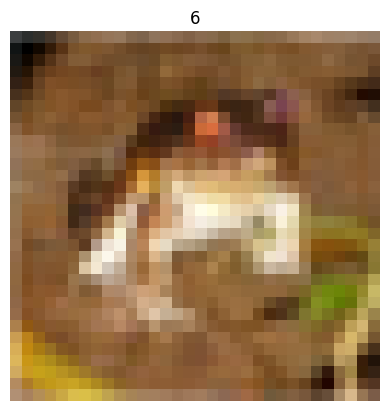

In [ ]:
image, label = train_data[0]

image = image.permute(1, 2, 0)
plt.imshow(image.squeeze())
plt.title(label)
plt.axis("off")

In [ ]:
from torch.utils.data import DataLoader

torch.manual_seed(42)

train_loader = DataLoader(
    dataset=train_data,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_data,
    shuffle=False
)

train_loader, test_loader

(<torch.utils.data.dataloader.DataLoader at 0x7dd5d71b8b20>,
 <torch.utils.data.dataloader.DataLoader at 0x7dd6747996f0>)

In [ ]:
len(train_loader), len(test_loader)

(782, 10000)

In [ ]:
examples = enumerate(train_loader)
batch_idx, (example_data, example_targets) = next(examples)

In [ ]:
example_data.shape, example_targets.shape

(torch.Size([64, 3, 32, 32]), torch.Size([64]))

In [ ]:
# Fire block
class FireBlock(nn.Module):
    def __init__(self, in_channels, squeeze_channels, expand1x1_channels, expand3x3_channels):
        super().__init__()
        self.squeeze = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=squeeze_channels, kernel_size=1),
            nn.BatchNorm2d(squeeze_channels),
            nn.ReLU()
        )
        self.expand1x1 = nn.Sequential(
            nn.Conv2d(in_channels=squeeze_channels, out_channels=expand1x1_channels, kernel_size=1),
            nn.BatchNorm2d(expand1x1_channels),
            nn.ReLU()
        )
        self.expand3x3 = nn.Sequential(
            nn.Conv2d(in_channels=squeeze_channels, out_channels=expand3x3_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(expand3x3_channels),
            nn.ReLU()
        )

    def forward(self, x: torch.Tensor):
        squeeze = self.squeeze(x)
        expand1x1 = self.expand1x1(squeeze)
        expand3x3 = self.expand3x3(squeeze)
        return torch.cat([expand1x1, expand3x3], dim=1)

In [ ]:
# SqueezeNet
class CNN(nn.Module):
    def __init__(self):
        super().__init__() # 3 x 32 x 32
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU()
        ) # 96 x 32 x 32
        self.MaxPool1 = nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True) # 96 x 16 x 16
        self.MaxPool2 = nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True)
        self.MaxPool3 = nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True)
        self.fire2 = FireBlock(in_channels=96, squeeze_channels=16, expand1x1_channels=64, expand3x3_channels=64) # 128 x 16 x 16
        #self.fire3 = FireBlock(in_channels=128, squeeze_channels=16, expand1x1_channels=64, expand3x3_channels=64) # 128 x 16 x 16
        self.fire4 = FireBlock(in_channels=128, squeeze_channels=32, expand1x1_channels=128, expand3x3_channels=128) # 256 x 16 x 16

        #self.fire5 = FireBlock(in_channels=256, squeeze_channels=32, expand1x1_channels=128, expand3x3_channels=128) # 256 x 8 x 8
        #self.fire6 = FireBlock(in_channels=256, squeeze_channels=48, expand1x1_channels=192, expand3x3_channels=192) # 384 x 8 x 8
        #self.fire7 = FireBlock(in_channels=384, squeeze_channels=48, expand1x1_channels=192, expand3x3_channels=192) # 384 x 8 x 8
        #self.fire8 = FireBlock(in_channels=384, squeeze_channels=64, expand1x1_channels=256, expand3x3_channels=256) # 512 x 8 x 8

        #self.fire9 = FireBlock(in_channels=512, squeeze_channels=64, expand1x1_channels=256, expand3x3_channels=256) # 512 x 4 x 4
        self.conv10 = nn.Sequential( # 384 x 4 x 4
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        ) # 1000 x 4 x 4
        self.avg_pool = nn.AvgPool2d(kernel_size=2, stride=2, ceil_mode=True) # 1000 x 2 x 2
        self.classifier = nn.Sequential(
            nn.Flatten(), # 1000 x 2 x 2
            nn.BatchNorm1d(256*4*4),
            nn.Dropout(p=0.35),
            nn.Linear(in_features=256*4*4, out_features=10)
        )

    def forward(self, x: torch.Tensor):
        x = self.conv1(x) # 96 x 32 x 32
        x = self.MaxPool1(x) # 96 x 16 x 16

        x = self.fire2(x) # 128 x 16 x 16
        #x = self.fire3(x) # 128 x 16 x 16
        #x = self.MaxPool2(x) # 256 x 8 x 8
        #x = self.fire4(x) # 256 x 16 x 16


        #x = self.fire5(x) # 256 x 8 x 8
        #x = self.fire6(x) # 384 x 8 x 8
        #x = self.fire7(x) # 384 x 8 x 8
        #x = self.fire8(x) # 512 x 8 x 8
        x = self.MaxPool3(x) # 512 x 4 x 4

        #x = self.fire9(x) # 512 x 4 x 4
        x = self.conv10(x) # 1000 x 4 x 4
        x = self.avg_pool(x) # 1000 x 2 x 2
        y = self.classifier(x)
        return y

In [ ]:
torch.manual_seed(42)

network = CNN().to(device)
network

CNN(
  (conv1): Sequential(
    (0): Conv2d(3, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (MaxPool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
  (MaxPool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
  (MaxPool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
  (fire2): FireBlock(
    (squeeze): Sequential(
      (0): Conv2d(96, 16, kernel_size=(1, 1), stride=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (expand1x1): Sequential(
      (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (expand3x3): Sequential(
      (0): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), paddi

In [ ]:
random_input_image = (1, 3, 32, 32)
random_input_image_error = (1, 3, 250, 250)

summary(CNN(),
        input_size=random_input_image,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
CNN (CNN)                                [1, 3, 32, 32]       [1, 10]              45,920               True
├─Sequential (conv1)                     [1, 3, 32, 32]       [1, 96, 32, 32]      --                   True
│    └─Conv2d (0)                        [1, 3, 32, 32]       [1, 96, 32, 32]      2,688                True
│    └─BatchNorm2d (1)                   [1, 96, 32, 32]      [1, 96, 32, 32]      192                  True
│    └─ReLU (2)                          [1, 96, 32, 32]      [1, 96, 32, 32]      --                   --
├─MaxPool2d (MaxPool1)                   [1, 96, 32, 32]      [1, 96, 16, 16]      --                   --
├─FireBlock (fire2)                      [1, 96, 16, 16]      [1, 128, 16, 16]     --                   True
│    └─Sequential (squeeze)              [1, 96, 16, 16]      [1, 16, 16, 16]      --                   True
│    │    └─Conv2d

In [ ]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=network.parameters(),
                            lr=0.001,
                            momentum=0.9,
                            weight_decay=0.001)

from helper_functions import accuracy_fn

In [ ]:
def train_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              optimizer: torch.optim.Optimizer,
              accuracy_fn,
              device):

    list_train_loss, list_train_acc = [], []
    train_loss, train_acc = 0, 0
    for batch, (X, y) in enumerate(data_loader):
        # Move X and y to the same device as the model
        X, y = X.to(device), y.to(device)

        # 1. forward pass
        y_pred = model(X)

        # 2. cal loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1))

        # 3. optimizer 0 grad
        optimizer.zero_grad()

        # 4. loss back
        loss.backward()

        # 5. optimizer step
        optimizer.step()

        if (batch + 1) % 100 == 0:
            train_loss_batch = train_loss / (batch + 1)
            train_acc_batch = train_acc / (batch + 1)
            print(f"Train batch: {batch + 1} | Train loss: {train_loss_batch:.5f} | Train acc: {train_acc_batch:.5f}")

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)

    list_train_loss.append(train_loss)
    list_train_acc.append(train_acc)

    print(f"Train loss: {train_loss:.5f} | Train acc: {train_acc:.5f}")
    return list_train_loss, list_train_acc

In [ ]:
def test_step(model: torch.nn.Module,
             data_loader: torch.utils.data.DataLoader,
             loss_fn: torch.nn.Module,
             accuracy_fn,
             device):

    list_test_loss, list_test_acc = [], []
    test_loss, test_acc = 0, 0
    model.eval()

    with torch.inference_mode():
        for batch, (X, y) in enumerate(data_loader):
            # Move X and y to the same device as the model
            X, y = X.to(device), y.to(device)

            test_pred = model(X)

            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                                    y_pred=test_pred.argmax(dim=1))

            if (batch + 1) % 2000 == 0:
                test_loss_batch = test_loss / (batch + 1)
                test_acc_batch = test_acc / (batch + 1)
                print(f"Test batch: {batch + 1} | Test loss: {test_loss_batch:.5f} | Test acc: {test_acc_batch:.5f}")

        test_loss /= len(data_loader)
        test_acc /= len(data_loader)

        list_test_loss.append(test_loss)
        list_test_acc.append(test_acc)

        print(f"Test loss: {test_loss:.5f} | Test acc: {test_acc:.5f}\n")
    return list_test_loss, list_test_acc

In [ ]:
torch.manual_seed(42)

from tqdm.auto import tqdm

epochs = 25

train_loss, train_acc = [], []
test_loss, test_acc = [], []

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}")

    train_loss_epoch, train_acc_epoch = train_step(model=network,
              data_loader=train_loader,
              loss_fn=loss_fn,
              optimizer=optimizer,
              accuracy_fn=accuracy_fn,
              device=device)

    test_loss_epoch, test_acc_epoch = test_step(model=network,
             data_loader=test_loader,
             loss_fn=loss_fn,
             accuracy_fn=accuracy_fn,
             device=device)

    train_loss.append(train_loss_epoch)
    train_acc.append(train_acc_epoch)
    test_loss.append(test_loss_epoch)
    test_acc.append(test_acc_epoch)

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 0
Train batch: 100 | Train loss: 1.74195 | Train acc: 38.87500
Train batch: 200 | Train loss: 1.60012 | Train acc: 43.84375
Train batch: 300 | Train loss: 1.51591 | Train acc: 46.97396
Train batch: 400 | Train loss: 1.45328 | Train acc: 49.33984
Train batch: 500 | Train loss: 1.40989 | Train acc: 50.98125
Train batch: 600 | Train loss: 1.37361 | Train acc: 52.22396
Train batch: 700 | Train loss: 1.34236 | Train acc: 53.42857
Train loss: 1.31811 | Train acc: 54.25991
Test batch: 2000 | Test loss: 1.09030 | Test acc: 61.70000
Test batch: 4000 | Test loss: 1.09285 | Test acc: 61.72500
Test batch: 6000 | Test loss: 1.08872 | Test acc: 62.41667
Test batch: 8000 | Test loss: 1.08870 | Test acc: 62.42500
Test batch: 10000 | Test loss: 1.09468 | Test acc: 62.17000
Test loss: 1.09468 | Test acc: 62.17000

Epoch: 1
Train batch: 100 | Train loss: 1.21844 | Train acc: 57.98438
Train batch: 200 | Train loss: 1.15575 | Train acc: 59.82031
Train batch: 300 | Train loss: 1.12774 | Train acc: 60

In [ ]:
# Convert train_loss to CPU and extract the scalar values
train_loss = [t[0].cpu().item() for t in train_loss]
test_loss = [t[0].cpu().item() for t in test_loss]

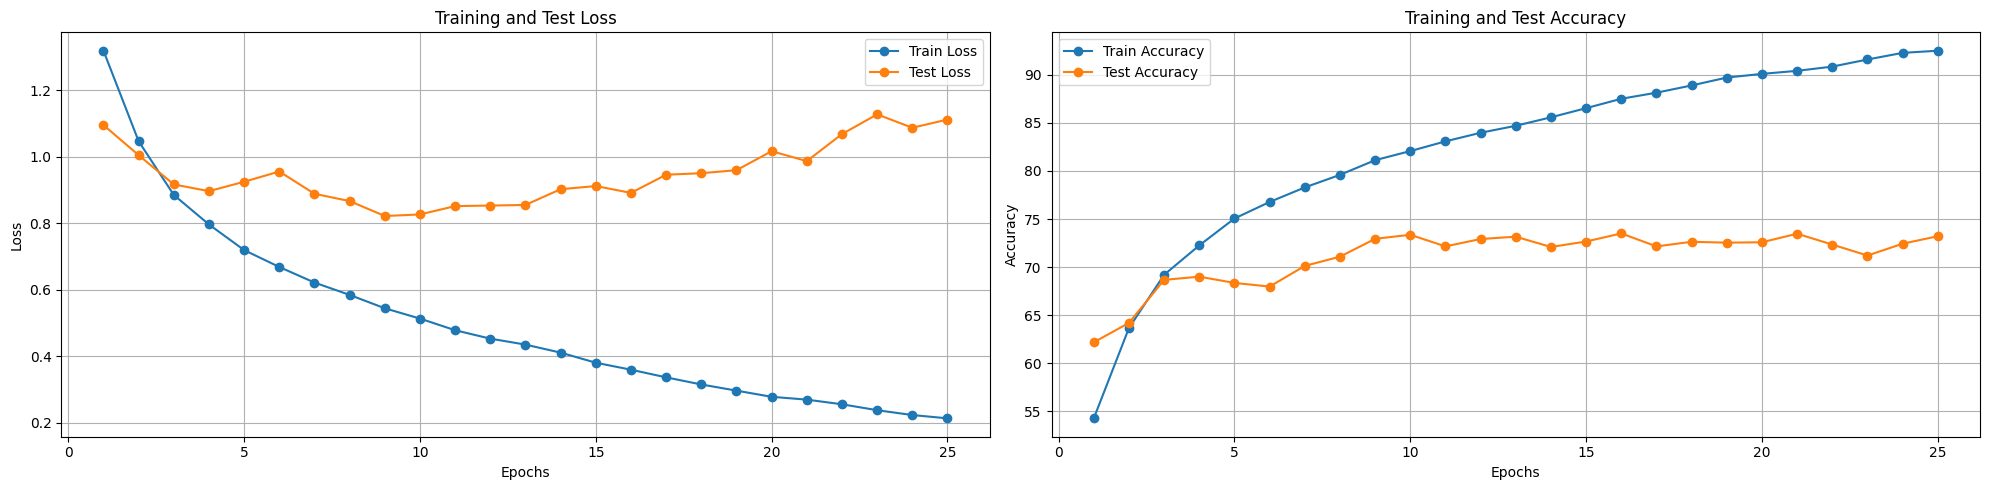

In [ ]:
# Create subplots with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Plot training and test loss on the first subplot
axes[0].plot(range(1, len(train_loss) + 1), train_loss, 'o-', label='Train Loss')
axes[0].plot(range(1, len(test_loss) + 1), test_loss, 'o-', label='Test Loss')
axes[0].set_title('Training and Test Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Plot training and test accuracy on the second subplot
axes[1].plot(range(1, len(train_acc) + 1), train_acc, 'o-', label='Train Accuracy')
axes[1].plot(range(1, len(test_acc) + 1), test_acc, 'o-', label='Test Accuracy')
axes[1].set_title('Training and Test Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

# Display the plots
plt.tight_layout()
plt.show()